# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line

## PROBLEMS Section 

page 90

#### 2.61

<img src="..//pics/Fig_P2_61.png" width=600> 


• A gazelle is running in a straight line (the x-axis). The graph in
Fig. P2.61 shows this animal’s velocity as a function of time. During
the first 12.0 s, find 

**(a)** the total distance moved and 

**(b)** the displacement
of the gazelle. 



In [ ]:
# Define symbolic variables
t, t1, t2, v0, v1, v2 = sp.symbols("t t_1 t_2 v_0 v_1 v_2", real=True)

# Slopes (accelerations)
a1_expr = (v1 - v0) / t1
a2_expr = (v2 - v1) / (t2 - t1)

# Areas under v-t curve (displacement / distance)
A1_expr = sp.Rational(1, 2) * (v0 + v1) * t1
A2_expr = sp.Rational(1, 2) * (v1 + v2) * (t2 - t1)
x_total_expr = A1_expr + A2_expr

display(Math(rf"a_1 = {sp.latex(a1_expr)}"))
display(Math(rf"a_2 = {sp.latex(a2_expr)}"))
display(Math(rf"\Delta x = {sp.latex(x_total_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Create Lambdified Functions from Cell 1 Expressions ---
calc_a1 = sp.lambdify((v0, v1, t1), a1_expr)
calc_a2 = sp.lambdify((v1, v2, t1, t2), a2_expr)
calc_x_total = sp.lambdify((v0, v1, v2, t1, t2), x_total_expr)

# --- 2. Astropy Physical Inputs ---
v0_qty = 4.00 * (u.m / u.s)
v1_qty = 12.0 * (u.m / u.s)
v2_qty = 0.0 * (u.m / u.s)

t1_qty = 10.0 * u.s
t2_qty = 12.0 * u.s

# --- 3. Evaluate Lambdified Functions using .value & Assign Quantities ---
a1_qty = calc_a1(v0_qty, v1_qty, t1_qty)
a2_qty = calc_a2(v1_qty, v2_qty, t1_qty, t2_qty)

x_tot_qty = calc_x_total(v0_qty, v1_qty, v2_qty, t1_qty, t2_qty)

print(f"Part (a) Total Distance  : {x_tot_qty:.2f}")
print(f"Part (b) Displacement    : {x_tot_qty:.2f}")
print(f"Part (c) Acceleration 1  : {a1_qty:.3f}")
print(f"Part (c) Acceleration 2  : -{a2_qty:.3f}")


Part (a) Total Distance  : 92.00 m
Part (b) Displacement    : 92.00 m
Part (c) Acceleration 1  : 0.800 m / s2
Part (c) Acceleration 2  : --6.000 m / s2


**(c)** Sketch an $a_x-t$ graph showing this gazelle’s acceleration as a function of time for the first 12.0 s.

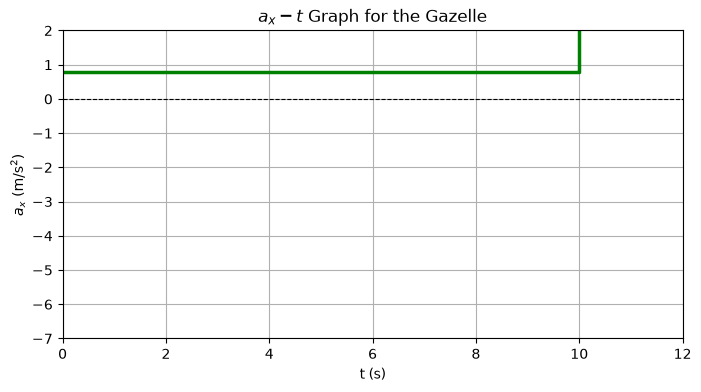

In [ ]:
# --- 4. Plot ax-t Graph ---
t_pts = [0, t1_qty.value, t1_qty.value, t2_qty.value]
a_pts = [a1_qty.value, a1_qty.value, -a2_qty.value, -a2_qty.value]

plt.figure(figsize=(8, 4))
plt.plot(t_pts, a_pts, "g-", lw=2.5)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title(r"$a_x - t$ Graph for the Gazelle")
plt.xlabel("t (s)")
plt.ylabel(r"$a_x\ (\mathrm{m/s^2})$")
plt.grid(True)
plt.xlim(0, 12.0)
plt.ylim(-7, 2)
plt.show()

#### 2.62

page 91

<img src="..//pics/Fig_P2_62.png" width=600> 

•• **Collision**. The engineer of a passenger train traveling at
25.0 m/s sights a freight train whose caboose is 200 m ahead on the
same track (Fig. P2.62). The freight train is traveling at 15.0 m/s in the
same direction as the passenger train. The engineer of the passenger
train immediately applies the brakes, causing a constant acceleration
of 0.100 m/s2 in a direction opposite to the train’s velocity, while the
freight train continues with constant speed. Take x = 0 at the location
of the front of the passenger train when the engineer applies the brakes.

**(a)** Will the cows nearby witness a collision? 

**(b)** If so, where will it take
place? 

**(c)** On a single graph, sketch the positions of the front of the passenger
train and the back of the freight train.

In [ ]:
import sympy as sp
from IPython.display import Math, display

# Define symbolic variables
t, x0_PT, v0_PT, a_PT, x0_FT, v0_FT = sp.symbols(
    "t x_{0PT} v_{0PT} a_{PT} x_{0FT} v_{0FT}", real=True
)

# Kinematic equations
x_PT_expr = x0_PT + v0_PT * t + sp.Rational(1, 2) * a_PT * t**2
x_FT_expr = x0_FT + v0_FT * t

# Solve for collision time
t_collision_roots = sp.solve(sp.Eq(x_PT_expr, x_FT_expr), t)

# Select the FIRST (smallest positive) root for physical collision
t_collision_expr = t_collision_roots[1]

# Location of collision
x_collision_expr = x_FT_expr.subs(t, t_collision_expr)

display(Math(rf"t_{{collision}} = {sp.latex(t_collision_expr)}"))
display(Math(rf"x_{{collision}} = {sp.latex(x_collision_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Part (a) Will there be a collision? : YES
Part (b) Collision Time            : 22.54 s
Part (b) Collision Location        : 538.10 m


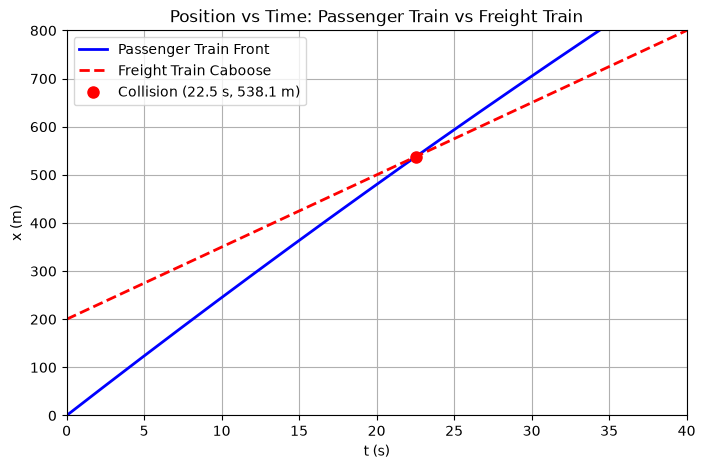

In [ ]:
# --- 1. Create Lambdified Functions from Cell 1 Expressions ---
calc_x_PT = sp.lambdify((t, x0_PT, v0_PT, a_PT), x_PT_expr)
calc_x_FT = sp.lambdify((t, x0_FT, v0_FT), x_FT_expr)
calc_t_collision = sp.lambdify((x0_PT, v0_PT, a_PT, x0_FT, v0_FT), t_collision_expr)
calc_x_collision = sp.lambdify((x0_PT, v0_PT, a_PT, x0_FT, v0_FT), x_collision_expr)

# --- 2. Astropy Physical Inputs ---
x0_PT_qty = 0.0 * u.m
v0_PT_qty = 25.0 * (u.m / u.s)
a_PT_qty = -0.100 * (u.m / u.s**2)

x0_FT_qty = 200.0 * u.m
v0_FT_qty = 15.0 * (u.m / u.s)

# --- 3. Evaluate Lambdified Functions ---
t_col_qty = (
    calc_t_collision(
        x0_PT_qty.value,
        v0_PT_qty.value,
        a_PT_qty.value,
        x0_FT_qty.value,
        v0_FT_qty.value,
    )
    * u.s
)

x_col_qty = (
    calc_x_collision(
        x0_PT_qty.value,
        v0_PT_qty.value,
        a_PT_qty.value,
        x0_FT_qty.value,
        v0_FT_qty.value,
    )
    * u.m
)

print(f"Part (a) Will there be a collision? : YES")
print(f"Part (b) Collision Time            : {t_col_qty:.2f}")
print(f"Part (b) Collision Location        : {x_col_qty:.2f}")

# --- 4. Plot Positions vs Time (Part c) ---
t_arr = np.linspace(0, 40, 200)
x_PT_arr = calc_x_PT(t_arr, x0_PT_qty.value, v0_PT_qty.value, a_PT_qty.value)
x_FT_arr = calc_x_FT(t_arr, x0_FT_qty.value, v0_FT_qty.value)

plt.figure(figsize=(8, 5))
plt.plot(t_arr, x_PT_arr, "b-", lw=2, label="Passenger Train Front")
plt.plot(t_arr, x_FT_arr, "r--", lw=2, label="Freight Train Caboose")
plt.plot(
    t_col_qty.value,
    x_col_qty.value,
    "ro",
    markersize=8,
    label=f"Collision ({t_col_qty.value:.1f} s, {x_col_qty.value:.1f} m)",
)

plt.title("Position vs Time: Passenger Train vs Freight Train")
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.grid(True)
plt.legend()
plt.xlim(0, 40)
plt.ylim(0, 800)
plt.show()

#### 2.63 

••• A ball starts from rest and rolls down a hill with uniform acceleration,
traveling 200 m during the second 5.0 s of its motion. How
far did it roll during the first 5.0 s of motion?

In [ ]:
# Define symbolic variables
a, t1, t2, dx2 = sp.symbols("a t_1 t_2 Deltax_2", real=True)

# Position equations starting from rest (v0 = 0, x0 = 0)
x1_expr = sp.Rational(1, 2) * a * t1**2
x2_expr = sp.Rational(1, 2) * a * t2**2

# Distance in second interval
dx2_expr = x2_expr - x1_expr

# Solve for acceleration 'a'
a_solved_expr = sp.solve(sp.Eq(dx2_expr, dx2), a)[0]

# Distance in first interval substituting solved acceleration
x1_final_expr = x1_expr.subs(a, a_solved_expr)

display(Math(rf"\Delta x_2 = {sp.latex(dx2_expr)}"))
display(Math(rf"a = {sp.latex(a_solved_expr)}"))
display(Math(rf"x_1 = {sp.latex(x1_final_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Create Lambdified Functions from Cell 1 Expressions ---
calc_a = sp.lambdify((dx2, t1, t2), a_solved_expr)
calc_x1 = sp.lambdify((dx2, t1, t2), x1_final_expr)

# --- 2. Astropy Physical Inputs ---
dx2_qty = 200.0 * u.m
t1_qty = 5.0 * u.s
t2_qty = 10.0 * u.s

# --- 3. Evaluate Lambdified Functions using .value & Assign Quantities ---
a_qty = calc_a(dx2_qty, t1_qty, t2_qty)
x1_qty = calc_x1(dx2_qty, t1_qty, t2_qty)

print(f"Calculated Acceleration : {a_qty:.4f}")
print(f"Distance in First 5.0 s : {x1_qty:.2f}")

Calculated Acceleration : 5.3333 m / s2
Distance in First 5.0 s : 66.67 m


#### 4.64

•• A rock moving in the +x-direction with speed 16.0 m/s has a
net force applied to it at time t = 0, and this produces a constant acceleration
in the -x-direction that has magnitude 4.00 m/s2. For what three
times t after the force is applied is the rock a distance of 24.0 m from its
position at t = 0? For each of these three values of t, what is the velocity
(magnitude and direction) of the rock?

In [ ]:
# Define symbolic variables
t, v0, a, d = sp.symbols("t v_0 a d", real=True)

# Kinematic equations
x_expr = v0 * t + sp.Rational(1, 2) * a * t**2
v_expr = v0 + a * t

# Solve for times when position is +d and -d
t_pos_roots = sp.solve(sp.Eq(x_expr, d), t)
t_neg_roots = sp.solve(sp.Eq(x_expr, -d), t)

# Explicitly order the roots physically:
# t1 = smaller positive root (+d)
# t2 = larger positive root (+d)
# t3 = positive root (-d)
t1_expr = sp.Min(t_pos_roots[0], t_pos_roots[1])
t2_expr = sp.Max(t_pos_roots[0], t_pos_roots[1])
t3_expr = sp.Max(t_neg_roots[0], t_neg_roots[1])

# Velocity expressions at each time
v1_expr = v_expr.subs(t, t1_expr)
v2_expr = v_expr.subs(t, t2_expr)
v3_expr = v_expr.subs(t, t3_expr)

display(Math(rf"t_1 = {sp.latex(t1_expr)}, \quad v_1 = {sp.latex(v1_expr)}"))
display(Math(rf"t_2 = {sp.latex(t2_expr)}, \quad v_2 = {sp.latex(v2_expr)}"))
display(Math(rf"t_3 = {sp.latex(t3_expr)}, \quad v_3 = {sp.latex(v3_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Create Lambdified Functions from Cell 1 Expressions ---
calc_times = sp.lambdify((v0, a, d), (t1_expr, t2_expr, t3_expr))
calc_vels = sp.lambdify((v0, a, d), (v1_expr, v2_expr, v3_expr))

# --- 2. Astropy Physical Inputs ---
v0_qty = 16.0 * (u.m / u.s)
a_qty = -4.00 * (u.m / u.s**2)
d_qty = 24.0 * u.m

# --- 3. Evaluate Lambdified Functions using .value & Assign Quantities ---
t1_qty, t2_qty, t3_qty = calc_times(v0_qty, a_qty, d_qty)
v1_qty, v2_qty, v3_qty = calc_vels(v0_qty, a_qty, d_qty)


print(f"t1 = {t1_qty:.2f}  -->  v1 = {v1_qty:.2f} (+x direction)")
print(f"t2 = {t2_qty:.2f}  -->  v2 = {v2_qty:.2f} (-x direction)")
print(f"t3 = {t3_qty:.2f}  -->  v3 = {v3_qty:.2f} (-x direction)")

t1 = 2.00 s  -->  v1 = 8.00 m / s (+x direction)
t2 = 6.00 s  -->  v2 = -8.00 m / s (-x direction)
t3 = 9.29 s  -->  v3 = -21.17 m / s (-x direction)


#### 2.65 
• A car and a truck start from rest at the same instant, with the
car initially at some distance behind the truck. The truck has a constant
acceleration of 2.10 m/s2, and the car has an acceleration of 3.40 m/s2.
The car overtakes the truck after the truck has moved 60.0 m. 

**(a)** How much time does it take the car to overtake the truck? 

**(b)** How far was
the car behind the truck initially? 

**(c)** What is the speed of each when
they are abreast? 



In [ ]:
# Define symbolic variables
x, t, a_t, a_c = sp.symbols("x, t, a_t, a_c", real=True)

# Kinematic equations
x_eq = sp.Eq(x, sp.Rational(1, 2) * a * t**2)
v_eq = sp.Eq(v, a * t)


# Solve for t
t_expr = sp.solve(x_eq, t)[1]
# Solve for x
x_expr = sp.solve(x_eq, x)[0]
# Solve for x
v_expr = sp.solve(v_eq, v)[0]


display(Math(rf"t = {sp.latex(t_expr)}"))
display(Math(rf"x = {sp.latex(x_expr)}"))
display(Math(rf"v = {sp.latex(v_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Create Lambdified Functions from Cell 1 Expressions ---
calc_t = sp.lambdify((x, a), t_expr)
calc_x = sp.lambdify((a, t), x_expr)
calc_v = sp.lambdify((a, t), v_expr)


# --- 2. Astropy Physical Inputs ---
a_truck_qty = 2.10 * (u.m / u.s**2)
a_car_qty = 3.40 * (u.m / u.s**2)
x_truck_qty = 60.0 * u.m

# --- 3. Evaluate Lambdified Functions using Quantities ---
t_qty = calc_t(x_truck_qty, a_truck_qty)
x_car_qty = calc_x(a_car_qty, t_qty)
v_car_qty = calc_v(a_car_qty, t_qty)
v_truck_qty = calc_v(a_truck_qty, t_qty)


print(f"Part (a): The car overtakes the track at t = {t_qty:.3g}")
print(f"Part (b): The car was at x = {x_truck_qty - x_car_qty:.3g} (behind the truck)")
print(f"Part (c): At time {t_qty:.3g}, overtake, the car was at v = {v_car_qty:.3g}")
print(
    f"Part (c): At time {t_qty:.3g}, overtake, the truck was at v = {v_truck_qty:.3g}"
)


Part (a): The car overtakes the track at t = 7.56 s
Part (b): The car was at x = -37.1 m (behind the truck)
Part (c): At time 7.56 s, overtake, the car was at v = 25.7 m / s
Part (c): At time 7.56 s, overtake, the truck was at v = 15.9 m / s


**(d)** On a single graph, sketch the position of each vehicle
as a function of time. Take x = 0 at the initial location of the truck.800701

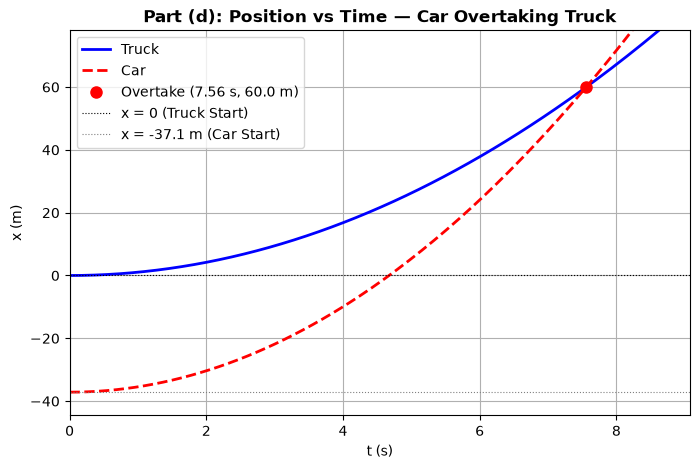

In [ ]:
# Create time array from t = 0 to slightly past overtake time
t_arr = np.linspace(0, t_qty.value * 1.2, 200)

# Evaluate positions using your lambdified calc_x function
# (Note: Truck starts at x = 0; Car starts at x = x_truck_qty - x_car_qty)
x_truck_arr = calc_x(a_truck_qty.value, t_arr)
x_car_arr = (x_truck_qty.value - x_car_qty.value) + calc_x(a_car_qty.value, t_arr)

# Initial car position for reference line
x_car_initial = x_truck_qty.value - x_car_qty.value

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t_arr, x_truck_arr, "b-", lw=2, label="Truck")
plt.plot(t_arr, x_car_arr, "r--", lw=2, label="Car")

# Highlight collision / overtake point
plt.plot(
    t_qty.value,
    x_truck_qty.value,
    "ro",
    markersize=8,
    label=f"Overtake ({t_qty.value:.2f} s, {x_truck_qty.value:.1f} m)",
)

# Reference dashed lines for origin and initial car position
plt.axhline(0, color="black", linewidth=0.8, linestyle=":", label="x = 0 (Truck Start)")
plt.axhline(
    x_car_initial,
    color="gray",
    linewidth=0.8,
    linestyle=":",
    label=f"x = {x_car_initial:.1f} m (Car Start)",
)

plt.title(
    "Part (d): Position vs Time — Car Overtaking Truck",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.grid(True)
plt.legend()
plt.xlim(0, t_arr[-1])
plt.ylim(x_car_initial * 1.2, x_truck_qty.value * 1.3)
plt.show()

#### 2.66 
•• You are standing at rest at a bus stop. A bus moving at a constant
speed of 5.00 m/s passes you. When the rear of the bus is 12.0 m
past you, you realize that it is your bus, so you start to run toward it with
a constant acceleration of 0.960 m/s2. How far would you have to run
before you catch up with the rear of the bus, and how fast must you be
running then? Would an average college student be physically able to
accomplish this?

In [ ]:
# Define symbolic variables
t, x0_B, v_B, a_Y = sp.symbols("t x0_B v_B a_Y", real=True)

# Kinematic position expressions
x_Y_expr = sp.Rational(1, 2) * a_Y * t**2
x_B_expr = x0_B + v_B * t

# Solve for catch-up time
t_roots = sp.solve(sp.Eq(x_Y_expr, x_B_expr), t)

# Select the positive time root (larger root since discriminant > 0 and c < 0)
t_catch_expr = sp.Max(t_roots[0], t_roots[1])

# Distance run and final velocity
x_catch_expr = x_Y_expr.subs(t, t_catch_expr)
v_catch_expr = a_Y * t_catch_expr

display(Math(rf"t_{{catch}} = {sp.latex(t_catch_expr)}"))
display(Math(rf"x_{{catch}} = {sp.latex(x_catch_expr)}"))
display(Math(rf"v_{{catch}} = {sp.latex(v_catch_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Lambdify Symbolic Expressions ---
calc_t = sp.lambdify((x0_B, v_B, a_Y), t_catch_expr)
calc_x = sp.lambdify((x0_B, v_B, a_Y), x_catch_expr)
calc_v = sp.lambdify((x0_B, v_B, a_Y), v_catch_expr)

# --- 2. Astropy Physical Inputs ---
x0_B_qty = 12.0 * u.m
v_B_qty = 5.00 * (u.m / u.s)
a_Y_qty = 0.960 * (u.m / u.s**2)

# --- 3. Evaluate Lambdified Functions using .value ---
t_qty = calc_t(x0_B_qty.value, v_B_qty.value, a_Y_qty.value) * u.s
x_qty = calc_x(x0_B_qty.value, v_B_qty.value, a_Y_qty.value) * u.m
v_qty = calc_v(x0_B_qty.value, v_B_qty.value, a_Y_qty.value) * (u.m / u.s)

print(f"Catch-up Time      : {t_qty:.2f}")
print(f"Distance to Run    : {x_qty:.2f}")
print(f"Final Runner Speed : {v_qty:.2f} ({v_qty.to(u.km / u.h):.2f})")
print("An average college student woould not be able to accomplish this.")

Catch-up Time      : 12.43 s
Distance to Run    : 74.14 m
Final Runner Speed : 11.93 m / s (42.95 km / h)
An average college student woould not be able to accomplish this.


#### 2.67 

•• A sprinter runs a 100 m dash in 12.0 s. She starts from rest
with a constant acceleration ax for 3.0 s and then runs with constant
speed for the remainder of the race. What is the value of ax?

In [ ]:
# Define symbolic variables
t, t1, t2, x, x1, x2, ax, v1 = sp.symbols("t t1 t2 x x1 x2 a_x v_1", real=True)

# Define system of equations
eq1 = sp.Eq(x, x1 + x2)
eq2 = sp.Eq(t2, t - t1)
eq3 = sp.Eq(x1, sp.Rational(1, 2) * ax * t1**2)
eq4 = sp.Eq(v1, ax * t1)
eq5 = sp.Eq(x2, v1 * t2)

# Solve system symbolically for acceleration ax
system = [eq1, eq2, eq3, eq4, eq5]
unknowns = [ax, x1, x2, v1, t2]
sol = sp.solve(system, unknowns, dict=True)[0]

ax_expr = sol[ax]
display(Math(rf"a_x = {sp.latex(ax_expr)}"))


<IPython.core.display.Math object>

In [ ]:
# --- 1. Lambdify Symbolic Expression ---
calc_ax = sp.lambdify((x, t, t1), ax_expr)

# --- 2. Astropy Physical Inputs ---
x_qty = 100 * u.m
t_qty = 12.0 * u.s
t1_qty = 3.0 * u.s

# --- 3. Evaluate Lambdified Function ---
ax_qty = calc_ax(x_qty, t_qty, t1_qty)

print(f"Acceleration ax = {ax_qty:.2f}")

Acceleration ax = 3.17 m / s2


### 2.70 

page 91

<img src="..//pics/Fig_P2_70.png" width=400> 

• **Egg Drop**. You are on the
roof of the physics building, 46.0 m
above the ground (Fig. P2.70). Your
physics professor, who is 1.80 m tall,
is walking alongside the building at
a constant speed of 1.20 m/s. If you
wish to drop an egg on your professor’s
head, where should the professor
be when you release the egg?
Assume that the egg is in free fall.

In [ ]:
# Define pure symbolic variables
y, y0, a, v = sp.symbols("y y0 a v", real=True)
t = sp.symbols("t", positive=True)
x = sp.symbols("x", real=True)

# Kinematic equations
y_eq = sp.Eq(y, y0 + sp.Rational(1, 2) * a * t**2)
v_eq = sp.Eq(v, x / t)

# Solve for t (positive root index [1]) and x
t_expr = sp.solve(y_eq, t)[1]
x_expr = sp.solve(v_eq, x)[0]

display(Math(rf"t = {sp.latex(t_expr)}"))
display(Math(rf"x = {sp.latex(x_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [187]:
# --- 1. Create Lambdified Functions ---
calc_t = sp.lambdify((y, y0, a), t_expr)
calc_x = sp.lambdify((t, v), x_expr)

# --- 2. Astropy Physical Inputs ---
h_B_qty = 46.0 * u.m  # Building height
h_P_qty = 1.80 * u.m  # Professor height
a_qty = -const.g0  # Gravitational acceleration (-9.81 m/s^2)
v_P_qty = 1.20 * (u.m / u.s)

y0_qty = h_B_qty
y_qty = h_P_qty

# --- 3. Evaluate by passing .value to lambdified functions ---
t_val = calc_t(y_qty.value, y0_qty.value, a_qty.value)


t_qty = t_val * u.s

x_val = calc_x(t_qty.value, v_P_qty.value)
x_P_qty = x_val * u.m

print(f"Fall time (t)            : {t_qty:.2f}")
print(f"Professor distance (x)  : {x_P_qty:.2f}")

Fall time (t)            : 3.00 s
Professor distance (x)  : 3.60 m


##### Simulation
$ python simulation_ch02_p2_70.py